In [1]:
!pip install pandas matplotlib seaborn evaluate rouge_score bert_score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 7.1 MB/s eta 0:00:00
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=7c63d12addf2836972e98fd759ece454a012b9cc53502d9081f62f0dd78c5030
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import evaluate
import re
from tqdm import tqdm
import os
from google.colab import drive

In [3]:
drive.mount('/content/drive/')
os.chdir("/content/drive/MyDrive/Tubes/Summarization/")

Mounted at /content/drive/


In [4]:
# --- CONFIGURATION ---
# Map your uploaded filenames to readable labels
FILES_CONFIG = {
    "BART (Full)": "experiment_full/Summarization Pipeline_BART_FULL.ipynb",
    "PEGASUS (Full)": "experiment_full/Summarization Pipeline_PEGASUS_FULL.ipynb",
    "BART (Sampled)": "experiment_sampled/Summarization Pipeline_BART_SAMPLED.ipynb",
    "PEGASUS (Sampled)": "experiment_sampled/Summarization Pipeline_PEGASUS_SAMPLED.ipynb"
}
CSV_PATH = "summary_experiment_test_results_final.csv"

# Define columns in your CSV corresponding to specific models
# Update these keys if your CSV column names differ slightly
MODEL_COL_MAPPING = {
    "BART (Full)": "summary_abs_finetuned_BART_FULL",
    "PEGASUS (Full)": "summary_abs_finetuned_PEGASUS_FULL",
    "BART (Sampled)": "summary_abs_finetuned_BART_SAMPLED",
    "PEGASUS (Sampled)": "summary_abs_finetuned_PEGASUS_SAMPLED",
    "BART (Baseline)": "summary_abs_zero_shot_BART",
    "PEGASUS (Baseline)": "summary_abs_zero_shot_PEGASUS",
    "Gemini Flash": "summary_decoder_gemini_flash_lite",
    "Baseline (First Sentence)": "summary_ext_first_sentence",
    "Baseline (TextRank)": "summary_ext_textrank"
}

--- Parsing Notebooks ---
Parsed BART (Full): 21 steps found.
Parsed PEGASUS (Full): 21 steps found.
Parsed BART (Sampled): 9 steps found.
Parsed PEGASUS (Sampled): 9 steps found.


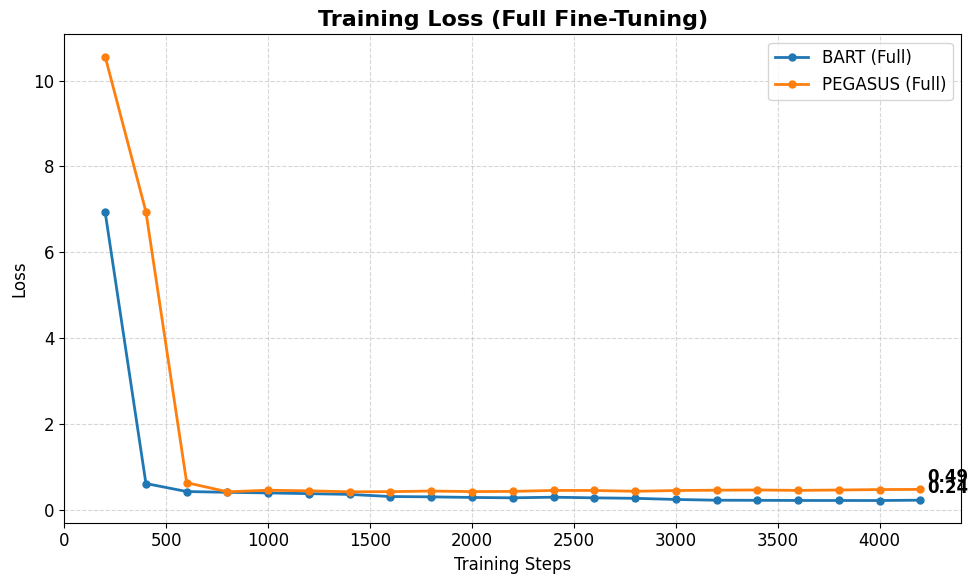

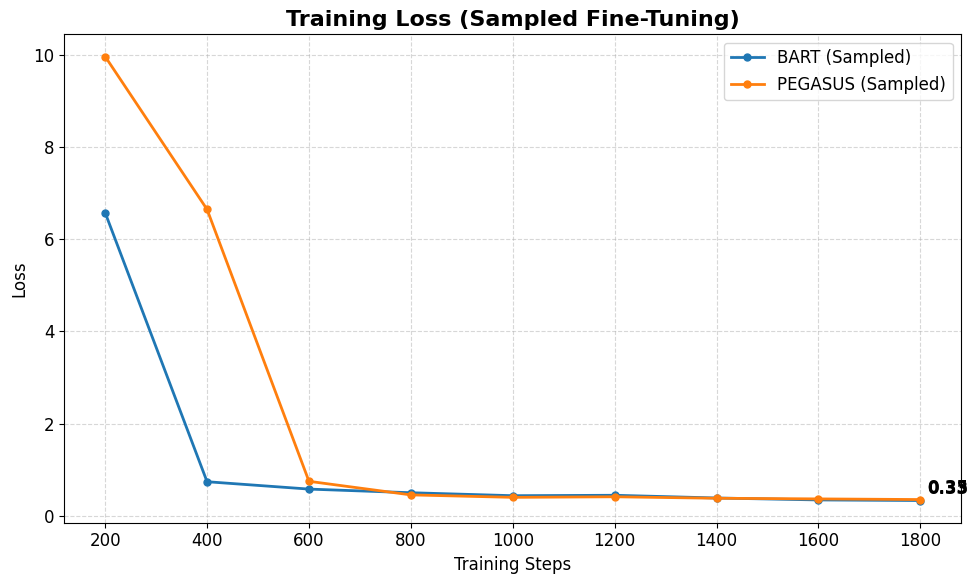

Done


In [5]:
# --- 1. PARSING FUNCTIONS ---
def parse_notebook(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        nb = json.load(f)

    loss_history = []

    for cell in nb['cells']:
        if cell['cell_type'] == 'code':
            for output in cell.get('outputs', []):
                # Text outputs
                if 'text' in output:
                    text_content = "".join(output['text'])
                    matches = re.findall(r"\{'loss':\s*([\d\.]+),\s*.*?,'epoch':\s*([\d\.]+),\s*'step':\s*(\d+)\}", text_content)
                    for m in matches:
                        loss_history.append({'loss': float(m[0]), 'epoch': float(m[1]), 'step': int(m[2])})

                # Data outputs
                if 'data' in output:
                    if 'text/html' in output['data']:
                        html_content = "".join(output['data']['text/html'])
                        rows = re.findall(r"<tr>\s*<td>(\d+)</td>\s*<td>([\d\.]+)</td>\s*</tr>", html_content)
                        for step, loss in rows:
                            loss_history.append({'loss': float(loss), 'step': int(step), 'epoch': None})

                    if 'text/plain' in output['data']:
                        content = "".join(output['data']['text/plain'])
                        matches = re.findall(r"\{'loss':\s*([\d\.]+),\s*.*?,'epoch':\s*([\d\.]+),\s*'step':\s*(\d+)\}", content)
                        for m in matches:
                            loss_history.append({'loss': float(m[0]), 'epoch': float(m[1]), 'step': int(m[2])})

    unique_history = {v['step']: v for v in loss_history}
    return sorted(unique_history.values(), key=lambda x: x['step'])

# --- 2. EXECUTION ---
print("--- Parsing Notebooks ---")
training_stats = {}
for label, filename in FILES_CONFIG.items():
    if os.path.exists(filename):
        history = parse_notebook(filename)
        training_stats[label] = {'history': history}
        print(f"Parsed {label}: {len(history)} steps found.")

plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

# --- SPLIT PLOTTING LOGIC ---
def plot_loss(stats_dict, title, filename_suffix):
    if not stats_dict:
        return

    plt.figure(figsize=(10, 6))
    has_data = False

    for label, stats in stats_dict.items():
        if stats['history']:
            has_data = True
            steps = [x['step'] for x in stats['history']]
            losses = [x['loss'] for x in stats['history']]

            # Color logic
            if "BART" in label: color = '#1f77b4'
            elif "PEGASUS" in label: color = '#ff7f0e'
            else: color = '#333333'

            plt.plot(steps, losses, marker='o', markersize=5, linewidth=2, label=label, color=color)
            if losses:
                plt.annotate(f'{losses[-1]:.2f}', (steps[-1], losses[-1]), xytext=(5, 5), textcoords='offset points', fontweight='bold')

    if has_data:
        plt.title(title, fontweight='bold', fontsize=16)
        plt.xlabel("Training Steps")
        plt.ylabel("Loss")
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend()
        plt.tight_layout()
        plt.savefig(f'training_loss_{filename_suffix}.png')
        plt.show()

# Split stats
full_stats = {k: v for k, v in training_stats.items() if "Full" in k or "FULL" in k}
sampled_stats = {k: v for k, v in training_stats.items() if "Sampled" in k or "SAMPLED" in k}

# Plot
plot_loss(full_stats, "Training Loss (Full Fine-Tuning)", "full")
plot_loss(sampled_stats, "Training Loss (Sampled Fine-Tuning)", "sampled")
print("Done")

--- Parsing Notebooks ---
Parsed BART (Full): 21 steps found.
Parsed PEGASUS (Full): 21 steps found.
Parsed BART (Sampled): 9 steps found.
Parsed PEGASUS (Sampled): 9 steps found.
Loading Metrics... (This may take a moment)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


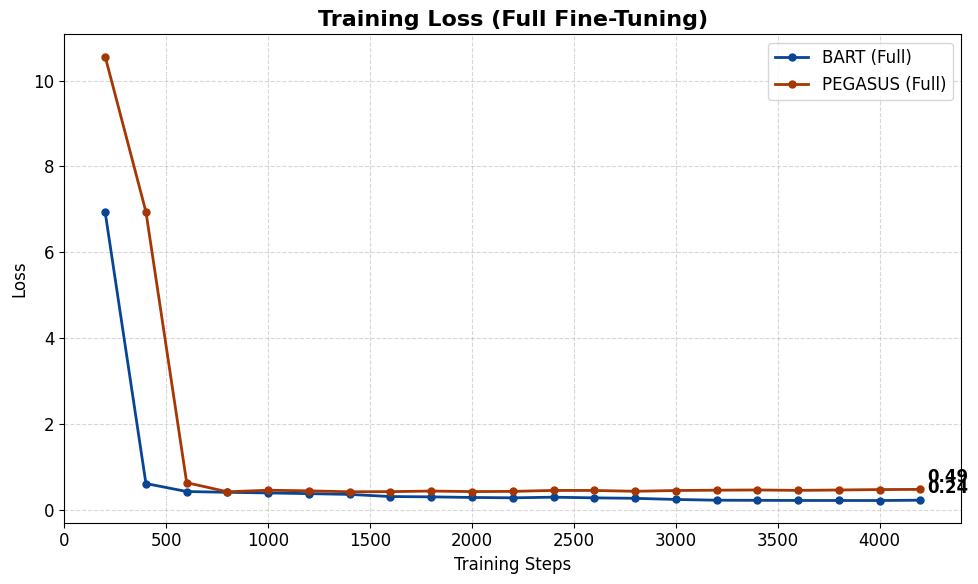

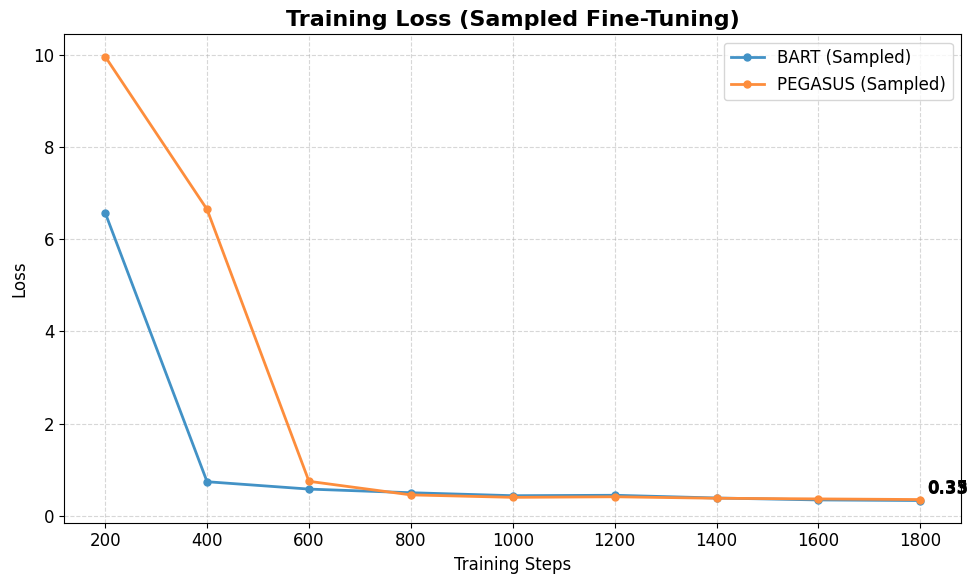

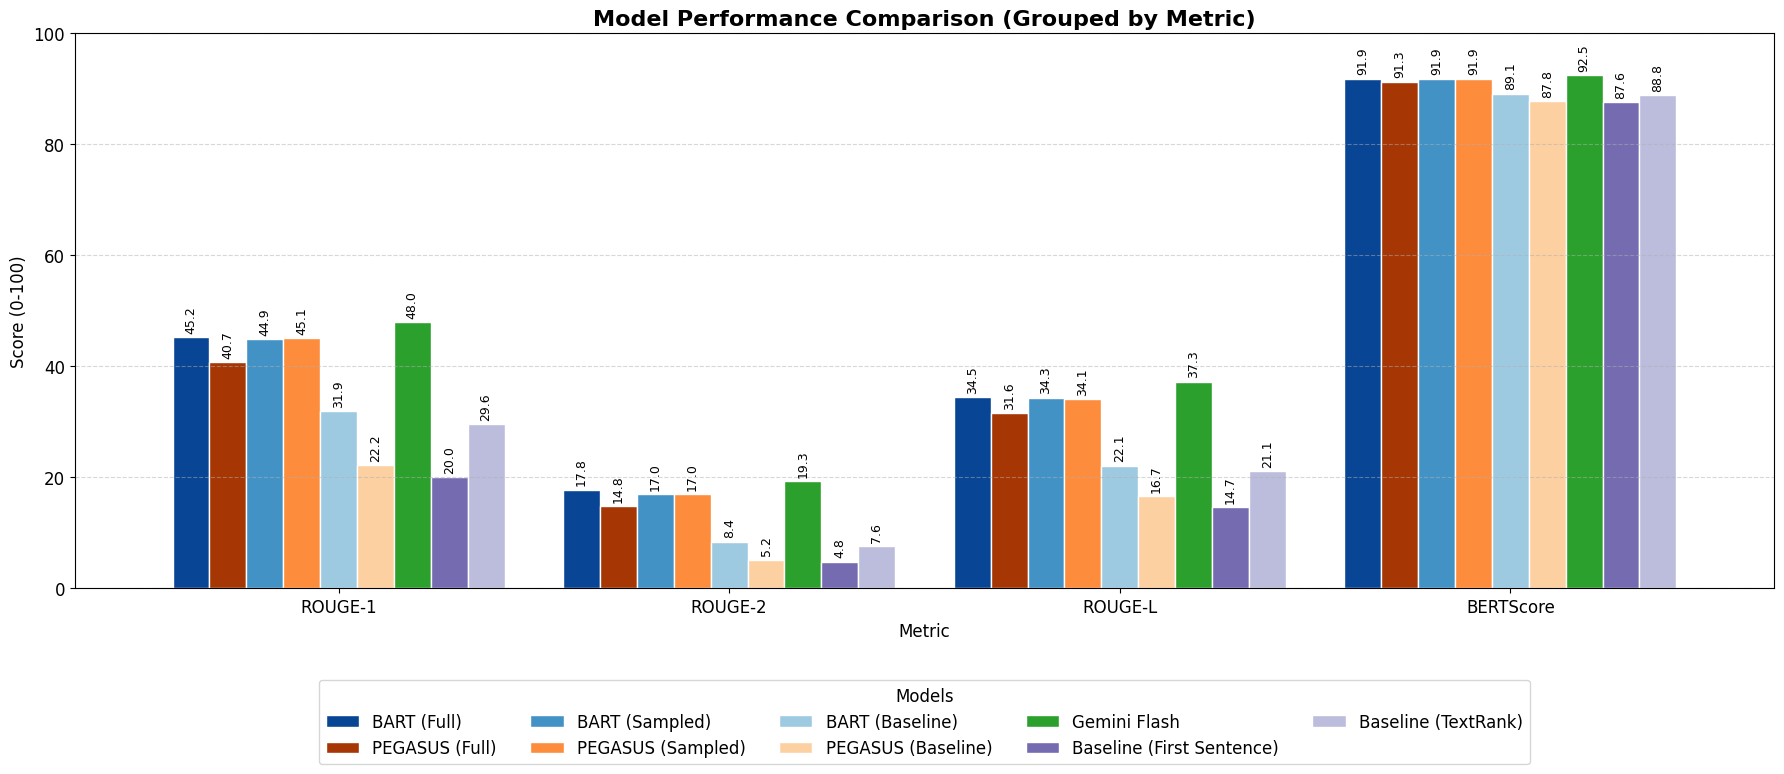

In [6]:
# --- 1. PARSING FUNCTIONS ---

def parse_notebook(filepath):
    """Parses a Jupyter Notebook to find Hugging Face training logs."""
    with open(filepath, 'r', encoding='utf-8') as f:
        nb = json.load(f)

    loss_history = []
    runtime = 0

    for cell in nb['cells']:
        if cell['cell_type'] == 'code':
            for output in cell.get('outputs', []):
                # 1. Text outputs
                if 'text' in output:
                    text_content = "".join(output['text'])
                    matches = re.findall(r"\{'loss':\s*([\d\.]+),\s*.*?,'epoch':\s*([\d\.]+),\s*'step':\s*(\d+)\}", text_content)
                    for m in matches:
                        loss_history.append({'loss': float(m[0]), 'epoch': float(m[1]), 'step': int(m[2])})

                    match_runtime = re.search(r"'train_runtime':\s*([\d\.]+)", text_content)
                    if match_runtime:
                        runtime = float(match_runtime.group(1)) / 60.0

                # 2. Data outputs (HTML tables)
                if 'data' in output:
                    if 'text/html' in output['data']:
                        html_content = "".join(output['data']['text/html'])
                        rows = re.findall(r"<tr>\s*<td>(\d+)</td>\s*<td>([\d\.]+)</td>\s*</tr>", html_content)
                        for step, loss in rows:
                            loss_history.append({'loss': float(loss), 'step': int(step), 'epoch': None})

                    if 'text/plain' in output['data']:
                        content = "".join(output['data']['text/plain'])
                        matches = re.findall(r"\{'loss':\s*([\d\.]+),\s*.*?,'epoch':\s*([\d\.]+),\s*'step':\s*(\d+)\}", content)
                        for m in matches:
                            loss_history.append({'loss': float(m[0]), 'epoch': float(m[1]), 'step': int(m[2])})

    unique_history = {v['step']: v for v in loss_history}
    return sorted(unique_history.values(), key=lambda x: x['step']), runtime

# --- 2. METRICS CALCULATION ---

def calculate_metrics(csv_path):
    print("Loading Metrics... (This may take a moment)")
    if not os.path.exists(csv_path):
        print(f"Error: CSV file '{csv_path}' not found.")
        return pd.DataFrame()

    df = pd.read_csv(csv_path)
    rouge = evaluate.load('rouge')
    bertscore = evaluate.load('bertscore')

    results = {}
    refs = df['summary'].tolist()

    for label, col_name in MODEL_COL_MAPPING.items():
        if col_name not in df.columns:
            print(f"Skipping {label} (Column {col_name} not found in CSV)")
            continue

        preds = df[col_name].fillna("").tolist()

        # ROUGE
        r_scores = rouge.compute(predictions=preds, references=refs)

        # BERTScore
        b_scores = bertscore.compute(predictions=preds, references=refs, lang="en")

        results[label] = {
            'ROUGE-1': r_scores['rouge1'] * 100,
            'ROUGE-2': r_scores['rouge2'] * 100,
            'ROUGE-L': r_scores['rougeL'] * 100,
            'BERTScore': np.mean(b_scores['f1']) * 100
        }
    return pd.DataFrame(results)

# --- 3. EXECUTION ---

# A. Extract Training Data
print("--- Parsing Notebooks ---")
training_stats = {}
for label, filename in FILES_CONFIG.items():
    if os.path.exists(filename):
        history, time_taken = parse_notebook(filename)
        training_stats[label] = {'history': history, 'time': time_taken}
        print(f"Parsed {label}: {len(history)} steps found.")
    else:
        print(f"File not found: {filename}")

# B. Calculate Metrics
df_metrics = calculate_metrics(CSV_PATH)

# --- 4. VISUALIZATION ---
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

# Colors (Consistent with Bar Plot)
loss_colors = {
    'BART (Full)': '#084594',        # Dark Blue
    'BART (Sampled)': '#4292c6',     # Light Blue
    'PEGASUS (Full)': '#a63603',     # Dark Orange
    'PEGASUS (Sampled)': '#fd8d3c'   # Light Orange
}

def plot_separated_loss(stats_subset, title, filename_suffix):
    if not stats_subset:
        return

    plt.figure(figsize=(10, 6))
    has_data = False

    for label, stats in stats_subset.items():
        if stats['history']:
            has_data = True
            steps = [x['step'] for x in stats['history']]
            losses = [x['loss'] for x in stats['history']]

            # Use strict color map or default to gray
            color = loss_colors.get(label, '#555555')

            plt.plot(steps, losses, marker='o', markersize=5, linewidth=2, label=label, color=color)
            if losses:
                plt.annotate(f'{losses[-1]:.2f}', (steps[-1], losses[-1]), xytext=(5, 5), textcoords='offset points', fontweight='bold')

    if has_data:
        plt.title(title, fontweight='bold', fontsize=16)
        plt.xlabel("Training Steps")
        plt.ylabel("Loss")
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend()
        plt.tight_layout()
        plt.savefig(f'training_loss_{filename_suffix}.png')
        plt.show()

# Separate Stats into Two Groups
full_stats = {k: v for k, v in training_stats.items() if "Full" in k or "FULL" in k}
sampled_stats = {k: v for k, v in training_stats.items() if "Sampled" in k or "SAMPLED" in k}

# Plot 1 & 2: Training Loss (Split)
plot_separated_loss(full_stats, "Training Loss (Full Fine-Tuning)", "full")
plot_separated_loss(sampled_stats, "Training Loss (Sampled Fine-Tuning)", "sampled")

# Plot 3: Performance Metrics (Grouped & Colored)
if not df_metrics.empty:
    # 1. Define Color Palette (Groups)
    model_palette = {
        # BART Group (Blues)
        'BART (Full)': '#084594',         # Dark Blue
        'BART (Sampled)': '#4292c6',      # Medium Blue
        'BART (Baseline)': '#9ecae1',     # Light Blue

        # PEGASUS Group (Oranges)
        'PEGASUS (Full)': '#a63603',      # Dark Orange
        'PEGASUS (Sampled)': '#fd8d3c',   # Medium Orange
        'PEGASUS (Baseline)': '#fdd0a2',  # Light Orange

        # Gemini (Green)
        'Gemini Flash': '#2ca02c',        # Green

        # Extractive Group (Purples)
        'Baseline (First Sentence)': '#756bb1', # Dark Purple
        'Baseline (TextRank)': '#bcbddc'        # Light Purple
    }

    # 2. Filter & Sort Data
    ordered_models = [m for m in MODEL_COL_MAPPING.keys() if m in df_metrics.columns]

    if ordered_models:
        plot_data = df_metrics[ordered_models]
        plot_colors = [model_palette.get(m, '#333333') for m in ordered_models]

        ax = plot_data.plot(kind='bar', figsize=(18, 8), width=0.85, color=plot_colors, edgecolor='white')

        plt.title("Model Performance Comparison (Grouped by Metric)", fontweight='bold', fontsize=16)
        plt.ylabel("Score (0-100)")
        plt.xlabel("Metric")
        plt.xticks(rotation=0, ha='center')

        plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5, title="Models")
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.ylim(0, 100)

        for container in ax.containers:
            ax.bar_label(container, fmt='%.1f', fontsize=9, padding=3, rotation=90)

        plt.tight_layout()
        plt.savefig('metrics_grouped_final.png')
        plt.show()

In [7]:
import pandas as pd
import evaluate
import numpy as np

# --- Configuration ---
RESULTS_FILE = "summary_experiment_test_results_final.csv"
GOLD_FILE = "gold_standard_summaries.csv"
OUTPUT_CSV = "error_analysis_report_percentiles.csv" # Changed filename

TARGET_COL = 'summary'
INPUT_COL = 'english_translation'

MODELS_TO_ANALYZE = [
    'summary_abs_finetuned_BART_FULL',
    'summary_abs_finetuned_PEGASUS_FULL',
    'summary_abs_finetuned_BART_SAMPLED',
    'summary_abs_finetuned_PEGASUS_SAMPLED'

]

def run_percentile_analysis(results_path, gold_path, output_path, models, ref_col, input_col):
    # 1. Load Data
    print(f"Loading Results: {results_path}")
    print(f"Loading Gold Standard: {gold_path}")

    try:
        df_res = pd.read_csv(results_path)
        df_gold = pd.read_csv(gold_path)
    except FileNotFoundError as e:
        print(f"Error: {e}")
        return

    # 2. Merge
    if 'id' in df_res.columns and 'id' in df_gold.columns:
        print("Merging files based on 'id' column...")
        if ref_col in df_res.columns: df_res = df_res.drop(columns=[ref_col])
        df = pd.merge(df_res, df_gold[['id', ref_col]], on='id', how='inner')
    else:
        print("'id' column missing. Merging by Index.")
        df = df_res.copy()
        df[ref_col] = df_gold[ref_col].values

    # 3. Metric
    print("⏳ Loading ROUGE metric...")
    rouge = evaluate.load("rouge")

    analysis_data = []

    # 4. Analyze
    for model_col in models:
        if model_col not in df.columns:
            print(f"Model '{model_col}' not found. Skipping...")
            continue

        print(f"Processing model: {model_col}...")

        preds = df[model_col].fillna("").astype(str).tolist()
        refs = df[ref_col].fillna("").astype(str).tolist()

        scores = rouge.compute(predictions=preds, references=refs, use_stemmer=True, use_aggregator=False)

        df_temp = df.copy()
        df_temp['rouge1_score'] = scores['rouge1']

        # Sort Lowest to Highest
        df_sorted = df_temp.sort_values(by='rouge1_score', ascending=True).reset_index(drop=True)

        n = len(df_sorted)
        if n == 0: continue

        # --- CHANGED LOGIC HERE ---
        # We ensure indices stay within bounds (0 to n-1)
        indices = {
            "10th Percentile (Poor)": int(n * 0.1),
            "50th Percentile (Median)": int(n * 0.5),
            "90th Percentile (Good)": int(n * 0.9)
        }

        for category, idx in indices.items():
            # Safety clamp (in case n is very small)
            idx = min(max(idx, 0), n - 1)

            row = df_sorted.iloc[idx]

            original_text = row[input_col] if input_col in row else ""
            input_length = len(str(original_text).split())

            analysis_data.append({
                'Model_Name': model_col,
                'Category': category,
                'ROUGE1_Score': row['rouge1_score'],
                'Input_Length_Words': input_length,
                'ID': row.get('id', 'N/A'),
                'Original_Input': original_text,
                'Gold_Summary': row[ref_col],
                'Generated_Summary': row[model_col]
            })

    # 5. Save
    if analysis_data:
        final_df = pd.DataFrame(analysis_data)
        cols = ['Model_Name', 'Category', 'ROUGE1_Score', 'Input_Length_Words', 'ID', 'Original_Input', 'Gold_Summary', 'Generated_Summary']
        final_df = final_df[cols]
        final_df.to_csv(output_path, index=False)
        print(f"\nSuccess! Saved to: {output_path}")
    else:
        print("\nNo data processed.")

run_percentile_analysis(RESULTS_FILE, GOLD_FILE, OUTPUT_CSV, MODELS_TO_ANALYZE, TARGET_COL, INPUT_COL)

Loading Results: summary_experiment_test_results_final.csv
Loading Gold Standard: gold_standard_summaries.csv
Merging files based on 'id' column...
⏳ Loading ROUGE metric...
Processing model: summary_abs_finetuned_BART_FULL...
Processing model: summary_abs_finetuned_PEGASUS_FULL...
Processing model: summary_abs_finetuned_BART_SAMPLED...
Processing model: summary_abs_finetuned_PEGASUS_SAMPLED...

Success! Saved to: error_analysis_report_percentiles.csv
